# **HAMC — Human-Inspired Adaptive Memory Consolidation**

## **1. Import Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

## **2. Reproducibility**

In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}\n")

TASK_CLASSES = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)]
N_TASKS      = len(TASK_CLASSES)

Using device: cuda



## **3. HAMC Buffer**

In [ ]:
class HAMCBuffer:
  def __init__(self, max_size: int = 2000):
    self.max_size = max_size
    self.xs: list = []
    self.ys: list = []
    self.zs: list = []
    self.feats: list = []
    self.mis: list = []
    self.was_correct: list = []
    self.task_ids: list = []
    self.per_task_quota = max_size // N_TASKS

  def add_single(
      self,
      x: torch.Tensor,
      y: torch.Tensor,
      z: torch.Tensor,
      feat: torch.Tensor,
      mis_score: float,
      correct: bool,
      task_id: int,
  ) -> None:
    task_count = sum(1 for t in self.task_ids if t == task_id)
    if task_count >= self.per_task_quota:
      candidate_indices = [
          i for i, t in enumerate(self.task_ids)
          if t == task_id
      ]
      if len(candidate_indices) > 0:
        local_mis = [self.mis[i] for i in candidate_indices]
        replace_idx = candidate_indices[np.argmin(local_mis)]

        if mis_score > self.mis[replace_idx]:
          self.xs[replace_idx] = x
          self.ys[replace_idx] = y
          self.zs[replace_idx] = z
          self.feats[replace_idx] = feat
          self.mis[replace_idx] = float(mis_score)
          self.was_correct[replace_idx] = bool(correct)
          self.task_ids[replace_idx] = task_id
      return

    if len(self.xs) < self.max_size:
      self.xs.append(x)
      self.ys.append(y)
      self.zs.append(z)
      self.feats.append(feat)
      self.mis.append(float(mis_score))
      self.was_correct.append(bool(correct))
      self.task_ids.append(task_id)

  def add_batch(
      self,
      xs: torch.Tensor,
      ys: torch.Tensor,
      zs: torch.Tensor,
      feats: torch.Tensor,
      mis_scores: torch.Tensor,
      corrects: torch.Tensor,
      task_id,
  ) -> None:
    for i in range(xs.size(0)):
      self.add_single(
          xs[i], ys[i], zs[i], feats[i],
          float(mis_scores[i]), bool(corrects[i]), task_id
      )

  def priority_sample(self, n_samples: int, device: torch.device):
    if len(self.xs) == 0:
      return None, None, None, None

    scores = np.array(self.mis, dtype=np.float64)
    scores = np.clip(scores, 1e-8, None)

    eps = 0.2
    priority_probs = scores/scores.sum()
    uniform_probs = np.ones(len(scores))/len(scores)
    probs = (1-eps) * priority_probs + eps * uniform_probs

    n = min(n_samples, len(self.xs))
    indices = np.random.choice(len(self.xs), n, replace=False, p=probs)

    x_out = torch.stack([self.xs[i] for i in indices]).to(device)
    y_out = torch.stack([self.ys[i] for i in indices]).to(device)
    z_out = torch.stack([self.zs[i] for i in indices]).to(device)
    feat_out = torch.stack([self.feats[i] for i in indices]).to(device)

    return x_out, y_out, z_out, feat_out

  def update_mis_and_forgetting(
      self,
      model: nn.Module,
      device: torch.device,
      w1: float = 0.3,
      w2: float = 0.1,
      w3: float = 0.2,
      w4: float = 0.4,
      batch_size: int = 128
  ) -> None:
    if len(self.xs) == 0:
      return

    N = len(self.xs)
    model.eval()

    with torch.no_grad():
      all_xs = torch.stack(self.xs).to(device)
      _, all_feats = model.forward_with_features(all_xs)
      if N > 1:
        dist_mat = torch.cdist(all_feats, all_feats)
        dist_mat.fill_diagonal_(float("inf"))
        novelty = dist_mat.min(dim=1).values
        N_norm = (novelty/novelty.max().clamp(min=1e-8)).cpu()
      else:
        N_norm = torch.ones(1)

      all_xs = torch.stack(self.xs)
      all_ys = torch.stack(self.ys)

      all_xs_gpu = all_xs.to(device)

      _, all_feats = model.forward_with_features(all_xs_gpu)

      batches_L, batches_U, batches_correct = [], [], []

      for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        xb = all_xs[start:end].to(device)
        yb = all_ys[start:end].to(device)

        logits_b, _ = model.forward_with_features(xb)

        Lb = F.cross_entropy(logits_b, yb, reduction="none")
        Lb = torch.clamp(Lb/2.303, 0.0, 1.0).cpu()
        batches_L.append(Lb)

        Ub = 1.0 - F.softmax(logits_b, dim=-1).max(dim=-1).values
        batches_U.append(Ub.cpu())

        correct_b = (logits_b.argmax(dim=-1) == yb).cpu()
        batches_correct.append(correct_b)

      all_L = torch.cat(batches_L)
      all_U = torch.cat(batches_U)
      all_correct = torch.cat(batches_correct)

      old_logits = torch.stack(self.zs).to(device)
      old_conf = F.softmax(old_logits, dim=-1).max(dim=-1).values
      new_logits, _ = model.forward_with_features(all_xs_gpu)
      new_conf = F.softmax(new_logits, dim=-1).max(dim=-1).values

      old_pred = old_logits.argmax(dim=1)
      new_pred = new_logits.argmax(dim=1)

      forgotten = (
          torch.tensor(self.was_correct)
          & (new_pred.cpu() != old_pred.cpu)
      )

      F_score = forgotten

      MIS = (w1 * all_L.float()
           + w2 * N_norm.float()
           + w3 * all_U.float()
           + w4 * F_score
      )

      self.mis = MIS.tolist()
      self.was_correct = all_correct.tolist()

    model.train()

  def get_stats(self) -> dict:
    if not self.mis:
      return {"size": 0, "mean": 0.0, "min": 0.0, "max": 0.0}
    m = np.array(self.mis)
    return {"size": len(self.xs),
            "mean": float(m.mean()),
            "min": float(m.min()),
            "max": float(m.max())}

  def __len__(self) -> int:
    return len(self.xs)

  def __repr__(self) -> str:
    s = self.get_stats()
    return (f"HAMCBuffer({s['size']}/{self.max_size} | "
            f"MIS mean={s['mean']:.3f} "
            f"min={s['min']:.3f} "
            f"max={s['max']:.3f})")

## **4. Neural Network**

In [ ]:
class MLP(nn.Module):
  def __init__(
    self,
    input_dim: int = 784,
    hidden_dim: int = 256,
    output_dim: int = 10
  ):
    super().__init__()
    self.feature_extractor = nn.Sequential(
      nn.Flatten(),
      nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.2),
      nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.2),
    )
    self.classifier = nn.Linear(hidden_dim, output_dim)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.classifier(self.feature_extractor(x))

  def forward_with_features(self, x: torch.Tensor):
    feats = self.feature_extractor(x)
    logits = self.classifier(feats)
    return logits, feats

## **5. Dataset - Split-MNIST**

In [ ]:
def build_split_mnist(data_root: str = "./data", batch_size: int = 128):
  tf = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize((0.1307,), (0.3081,))
  ])
  train_ds = torchvision.datasets.MNIST(data_root, train=True, download=True, transform=tf)
  test_ds = torchvision.datasets.MNIST(data_root, train=False, download=True, transform=tf)

  print(f"Split-MNIST - {N_TASKS} tasks:")
  loaders = []
  for t, (c0, c1) in enumerate(TASK_CLASSES):
    tr_idx = [i for i, (_, y) in enumerate(train_ds) if y in (c0, c1)]
    te_idx = [i for i, (_, y) in enumerate(test_ds) if y in (c0, c1)]
    tr = DataLoader(Subset(train_ds, tr_idx), batch_size=batch_size, shuffle=True)
    te = DataLoader(Subset(test_ds, te_idx), batch_size=256, shuffle=False)
    print(f"  Task {t+1}: digits {c0}&{c1}  |  train={len(tr_idx):,}  test={len(te_idx):,}")
    loaders.append((tr, te))
  return loaders

## **6. MIS Computation**

In [ ]:
def compute_mis_batch(
  logits: torch.Tensor,
  feats: torch.Tensor,
  ys: torch.Tensor,
  buf_feats: torch.Tensor,
  w1: float, w2: float, w3: float, w4: float
) -> torch.Tensor:
  B = logits.size(0)
  device = logits.device

  L = F.cross_entropy(logits, ys, reduction="none")
  L = torch.clamp(L/2.303, 0.0, 1.0)

  U = 1.0 - F.softmax(logits, dim=-1).max(dim=-1).values

  if buf_feats is not None and buf_feats.size(0) > 0:
    dists = torch.cdist(feats, buf_feats)
    N_raw = dists.min(dim=1).values
    N = N_raw/N_raw.max().clamp(min=1e-8)
  else:
    N = torch.ones(B, device=device)

  F_score = torch.zeros(B, device=device)

  return w1 * L + w2 * N + w3 * U + w4 * F_score

## **7. HAMC Training Step**

In [ ]:
def train_epoch_hamc(
    model: nn.Module,
    optimizer: optim.Optimizer,
    cur_loader: DataLoader,
    buffer: HAMCBuffer,
    device: torch.device,
    task_id,
    alpha: float = 1.0,
    beta: float = 2.0,
    gamma: float = 0.3,
    replay_bs: int = 128,
    w: tuple = (0.3, 0.1, 0.2, 0.4),
):
  model.train()
  w1, w2, w3, w4 = w
  sum_l_cur = sum_l_dist = sum_l_rep = sum_l_feat = 0.0
  n_steps = 0

  for x_cur, y_cur in cur_loader:
    x_cur = x_cur.to(device)
    y_cur = y_cur.to(device)

    optimizer.zero_grad()

    logits_cur, feats_cur = model.forward_with_features(x_cur)
    l_current = F.cross_entropy(logits_cur, y_cur)

    x_buf, y_buf, z_buf, feat_buf_old = buffer.priority_sample(replay_bs, device)

    l_distill = torch.tensor(0.0, device=device)
    l_replay = torch.tensor(0.0, device=device)
    l_feat = torch.tensor(0.0, device=device)

    if x_buf is not None:
      logits_buf, feats_buf = model.forward_with_features(x_buf)
      T = 0.2
      l_distill = F.kl_div(
          F.log_softmax(logits_buf/T, dim=1),
          F.softmax(z_buf/T, dim=1),
          reduction="batchmean"
      ) * (T * T)

      l_replay = F.cross_entropy(logits_buf, y_buf)
      l_feat = F.mse_loss(feats_buf, feat_buf_old)

    gamma = 0.3

    loss = (
        l_current
        + alpha * l_distill
        + beta * l_replay
        + gamma * l_feat
    )

    loss.backward()
    optimizer.step()

    with torch.no_grad():
      buf_feats_t = (torch.stack(buffer.feats).to(device)
                     if len(buffer.feats) > 0 else None
      )

      mis_scores = compute_mis_batch(
          logits_cur.detach(), feats_cur.detach(),
          y_cur, buf_feats_t,
          w1, w2, w3, w4,
      )

      is_correct = (logits_cur.detach().argmax(dim=-1) == y_cur)

      buffer.add_batch(
          x_cur.cpu(), y_cur.cpu(),
          logits_cur.detach().cpu(),
          feats_cur.detach().cpu(),
          mis_scores.cpu(),
          is_correct.cpu(),
          task_id
      )

    sum_l_cur  += l_current.item()
    sum_l_dist += l_distill.item()
    sum_l_rep  += l_replay.item()
    sum_l_feat += l_feat.item()
    n_steps += 1

  return (
      sum_l_cur  / n_steps,
      sum_l_dist / n_steps,
      sum_l_rep  / n_steps,
      sum_l_feat / n_steps
  )


## **8. Evaluation**

In [ ]:
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device
) -> float:
  model.eval()
  correct = total = 0
  for x, y in loader:
    x, y = x.to(device), y.to(device)
    preds = model(x).argmax(dim=1)
    correct += (preds == y).sum().item()
    total += y.size(0)
  return 100.0 * correct / total

## **9. Continual Learning Loop**

In [ ]:
def run_hamc(
    task_loaders,
    n_epochs: int = 5,
    lr: float = 3e-4,
    alpha: float = 1.0,
    beta: float = 2.0,
    replay_buffer_size: int = 5000,
    replay_batch_size: int = 128,
    mis_weights: tuple = (0.3, 0.1, 0.2, 0.4),
    device: torch.device = DEVICE
):
  print(f"\n{'=' * 65}")
  print(f"  HAMC — Human-Inspired Adaptive Memory Consolidation")
  print(f"  α={alpha} (distill)  β={beta} (replay CE)")
  print(f"  MIS weights  w=(L={mis_weights[0]}, N={mis_weights[1]}, "
          f"U={mis_weights[2]}, F={mis_weights[3]})")
  print(f"  buffer={replay_buffer_size}   replay_bs={replay_batch_size}")
  print(f"{'═' * 65}")

  model = MLP().to(device)
  optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
  buffer = HAMCBuffer(max_size=replay_buffer_size)

  acc_matrix = np.zeros((N_TASKS, N_TASKS))
  loss_history = []
  mis_history = []

  w1, w2, w3, w4 = mis_weights

  for task_id, (tr_loader, _) in enumerate(task_loaders):
    c0, c1 = TASK_CLASSES[task_id]
    print(f"\n  ┌── Task {task_id+1}/{N_TASKS} | digits {c0}&{c1} | {len(tr_loader.dataset):,} samples")

    for epoch in range(1, n_epochs + 1):
      l_cur, l_dist, l_rep, l_feat = train_epoch_hamc(
          model, optimizer, tr_loader, buffer, device, task_id,
          alpha=alpha, beta=beta, replay_bs=replay_batch_size,
          w=mis_weights
      )

      buffer.update_mis_and_forgetting(model, device, w1, w2, w3, w4)

      stats = buffer.get_stats()
      loss_history.append((task_id, epoch, l_cur, l_dist, l_rep))
      mis_history.append((task_id, epoch, stats["mean"], stats["min"], stats["max"]))

      print(f"  │  Epoch {epoch}/{n_epochs} | "
            f"L_cur={l_cur:.4f}  L_dist={l_dist:.4f}  L_rep={l_rep:.4f}  "
            f"| {buffer}"
          )

    print(f"  │  Buffer updated → {len(buffer)}/{buffer.max_size}")

    print(f"  │  Accuracy:")
    for j in range(task_id + 1):
      acc = evaluate(model, task_loaders[j][1], device)
      acc_matrix[task_id, j] = acc
      c0j, c1j = TASK_CLASSES[j]
      tag = "  ◄ trained now" if j == task_id else ""
      print(f"  │    Task {j+1} (digits {c0j}&{c1j}): {acc:6.2f}%{tag}")

    print(f"  └{'─' * 57}")

  final_accs = acc_matrix[-1, :]
  print(f"\n  Final Average Accuracy : {final_accs.mean():.2f}%")
  print(f"  Per-task               : {np.round(final_accs, 1)}")

  return acc_matrix, loss_history, mis_history

## **10. Plotting**

In [ ]:
def plot_results(acc_matrix: np.ndarray) -> None:
  fig, ax = plt.subplots(figsize=(8, 6))
  fig.suptitle(
      "HAMC — Human-Inspired Adaptive Memory Consolidation\n"
      "Split-MNIST (5 Tasks)",
      fontsize=13, fontweight="bold"
  )

  masked = np.where(np.tri(N_TASKS, dtype=bool), acc_matrix, np.nan)
  im = ax.imshow(masked, vmin=0, vmax=100, cmap="Blues", aspect="auto")
  plt.colorbar(im, ax=ax, shrink=0.82, label="Accuracy (%)")

  ax.set_xticks(range(N_TASKS))
  ax.set_yticks(range(N_TASKS))
  ax.set_xticklabels([f"Task {i+1}" for i in range(N_TASKS)])
  ax.set_yticklabels([f"After T{i+1}" for i in range(N_TASKS)])
  ax.set_xlabel("Evaluated on Task →")
  ax.set_ylabel("After Training on Task →")
  ax.set_title("Accuracy Matrix", fontweight="bold")

  for i in range(N_TASKS):
    for j in range(i + 1):
      v = acc_matrix[i, j]
      fc = "white" if v < 45 else "black"
      ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                     fontsize=9, fontweight="bold", color=fc)

  plt.tight_layout()
  plt.show()

## **11. Main Loop**

Loading Split-MNIST
Split-MNIST - 5 tasks:
  Task 1: digits 0&1  |  train=12,665  test=2,115
  Task 2: digits 2&3  |  train=12,089  test=2,042
  Task 3: digits 4&5  |  train=11,263  test=1,874
  Task 4: digits 6&7  |  train=12,183  test=1,986
  Task 5: digits 8&9  |  train=11,800  test=1,983

  HAMC — Human-Inspired Adaptive Memory Consolidation
  α=1.0 (distill)  β=2.0 (replay CE)
  MIS weights  w=(L=0.3, N=0.1, U=0.2, F=0.4)
  buffer=5000   replay_bs=128
═════════════════════════════════════════════════════════════════

  ┌── Task 1/5 | digits 0&1 | 12,665 samples
  │  Epoch 1/5 | L_cur=0.1224  L_dist=0.2965  L_rep=0.1243  | HAMCBuffer(1000/5000 | MIS mean=0.399 min=0.021 max=0.658)
  │  Epoch 2/5 | L_cur=0.0155  L_dist=0.1587  L_rep=0.0208  | HAMCBuffer(1000/5000 | MIS mean=0.444 min=0.401 max=0.549)
  │  Epoch 3/5 | L_cur=0.0121  L_dist=0.1512  L_rep=0.0157  | HAMCBuffer(1000/5000 | MIS mean=0.447 min=0.401 max=0.534)
  │  Epoch 4/5 | L_cur=0.0107  L_dist=0.1477  L_rep=0.0145  | HA

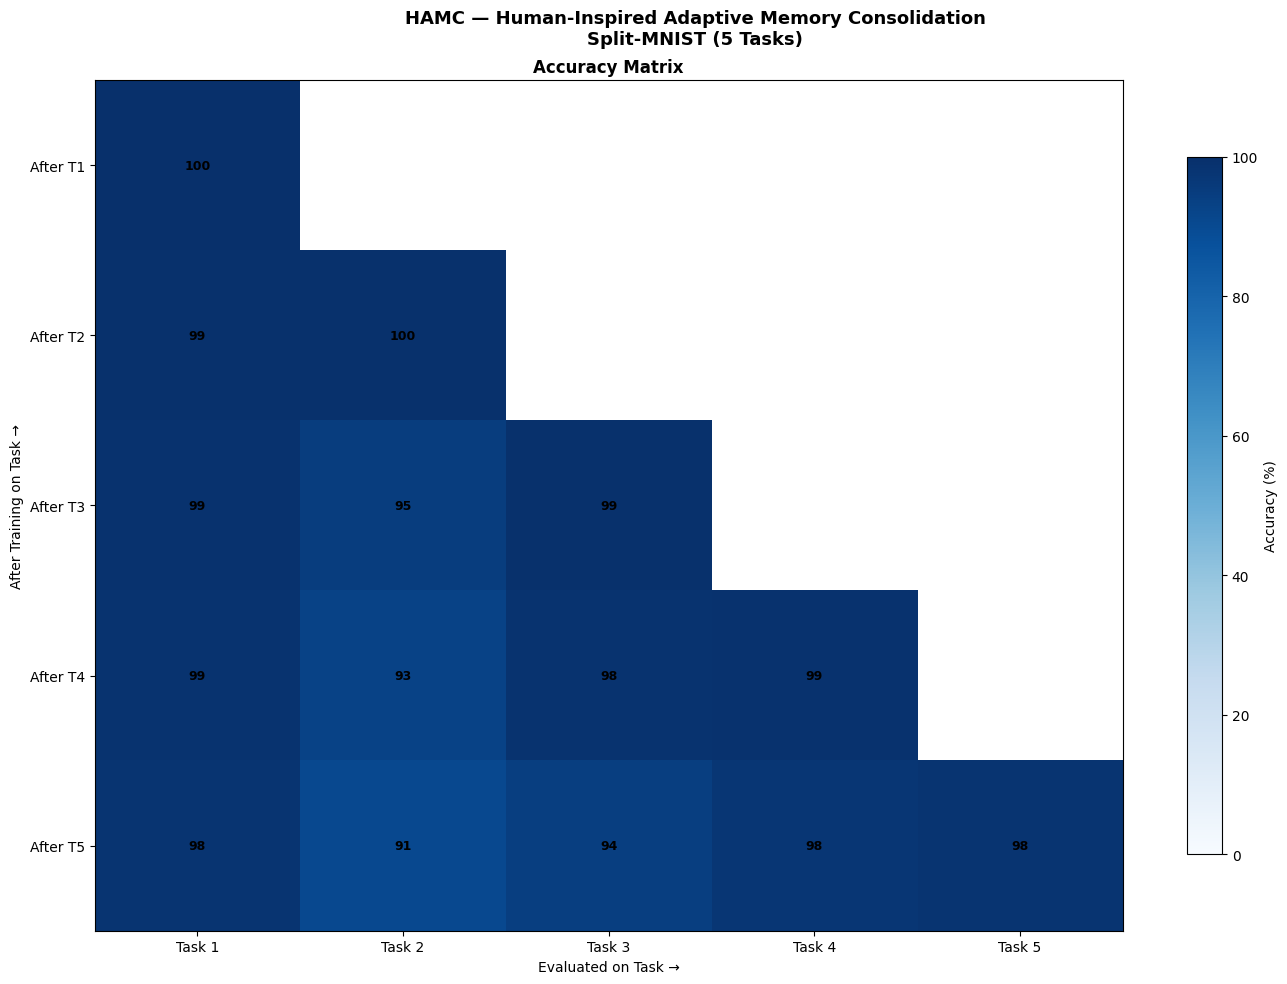


Done! ✓


In [ ]:
if __name__ == "__main__":
  print("Loading Split-MNIST")
  task_loaders = build_split_mnist(data_root = "./data", batch_size = 64)

  N_EPOCHS = 5
  acc_matrix, loss_history, mis_history = run_hamc(
      task_loaders,
      n_epochs = N_EPOCHS,
      lr = 3e-4,
      alpha = 1.0,
      beta = 2.0,
      replay_buffer_size = 5000,
      replay_batch_size = 128,
      mis_weights = (0.3, 0.1, 0.2, 0.4),
      device = DEVICE
  )

  plot_results(acc_matrix)

  print("\nDone! ✓")